# Explore the dataset

In [3]:
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS

In [15]:
a = RDF.type
ontolex = Namespace('http://www.w3.org/ns/lemon/ontolex#')
der = Namespace('https://github.com/adamfengxx/italian-derivmorph-small/wfr#')

In [2]:
g = Graph()
g.parse('affixes.ttl')
g.parse('./lexical_entries.ttl')
g.parse('./wfr.ttl')

<Graph identifier=N86e360a49ba7410dab5dcf1dae54e9ac (<class 'rdflib.graph.Graph'>)>

In [24]:
ns = {"lex": "https://github.com/adamfengxx/italian-derivmorph-small/lexical_entries#",
"mor": "https://github.com/adamfengxx/italian-derivmorph-small/morph#",
"der": "https://github.com/adamfengxx/italian-derivmorph-small/wfr#",
"morph": "http://www.w3.org/ns/lemon/morph#",
"vartrans": "http://www.w3.org/ns/lemon/vartrans#",
"ontolex": "http://www.w3.org/ns/lemon/ontolex#",
"rdf": "http://www.w3.org/1999/02/22-rdf-syntax-ns#",
"rdfs": "http://www.w3.org/2000/01/rdf-schema#"}

for k, v in ns.items():
    g.bind(k, v)

In [10]:
lex_entries = [l for l in g.subjects(a, ontolex.LexicalEntry)]
len(lex_entries)

16020

In [14]:
for p, o in g.predicate_objects(lex_entries[0]):
    print(p, o)

http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://www.w3.org/ns/lemon/ontolex#LexicalEntry
http://www.w3.org/2000/01/rdf-schema#label abbassamento
http://www.w3.org/ns/lemon/ontolex#canonicalForm http://liita.it/data/id/lemma/959890


In [16]:
for p, o in g.predicate_objects(der.r_3940):
    print(p, o)

http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://www.w3.org/ns/lemon/morph#WordFormationRelation
http://www.w3.org/ns/lemon/vartrans#source https://github.com/adamfengxx/italian-derivmorph-small/lexical_entries#b_460
http://www.w3.org/ns/lemon/vartrans#target https://github.com/adamfengxx/italian-derivmorph-small/lexical_entries#l_1
http://www.w3.org/ns/lemon/morph#wordFormationRule https://github.com/adamfengxx/italian-derivmorph-small/wfr#r_3940_wfp1
http://www.w3.org/ns/lemon/morph#wordFormationRule https://github.com/adamfengxx/italian-derivmorph-small/wfr#r_3940_wfp2
http://www.w3.org/ns/lemon/morph#wordFormationRule https://github.com/adamfengxx/italian-derivmorph-small/wfr#r_3940_wfp3
http://www.w3.org/1999/02/22-rdf-syntax-ns#_1 https://github.com/adamfengxx/italian-derivmorph-small/wfr#r_3940_wfp1
http://www.w3.org/1999/02/22-rdf-syntax-ns#_2 https://github.com/adamfengxx/italian-derivmorph-small/wfr#r_3940_wfp2
http://www.w3.org/1999/02/22-rdf-syntax-ns#_3 https://githu

In [35]:
c = 0
for s in g.subjects(a, ontolex.Form):
    c += 1
print(c)

1009


In [37]:
linked = []
not_linked = []

for s,_,o in g.triples((None, ontolex.canonicalForm, None)):
    if str(o).startswith('http://liita.it/data'):
        linked.append(s)
    else:
        not_linked.append(s)

print('Linked: ', len(linked) )
print('Not linked ', len(not_linked))

Linked:  15128
Not linked  1009


In [38]:
for nl in not_linked[:5]:
    for lab in g.objects(nl, RDFS.label):
        print(lab)

-iere
-1aio
-1eria
-1ino
-1one


In [20]:
from rdflib.extras.external_graph_libs import rdflib_to_networkx_multidigraph
import networkx as nx
import matplotlib.pyplot as plt

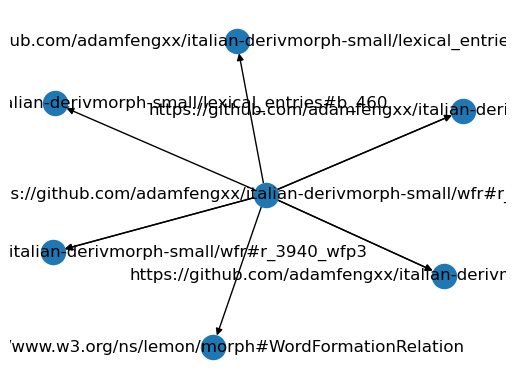

In [ ]:
result = g.triples((der.r_3940, None, None))

G = rdflib_to_networkx_multidigraph(result)

# Plot Networkx instance of RDF Graph
pos = nx.spring_layout(G, scale=2)
edge_labels = nx.get_edge_attributes(G, 'r')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
nx.draw(G, with_labels=True)

#if not in interactive mode for 
plt.show()

In [26]:
edge_labels

{}